In [2]:
import sys

sys.path.append("../src/")

import matplotlib.pyplot as plt
import torch
from imagegenerator import ImageGenerator
from pdb2mrc import PDB2MRC
from plotting_tools import *
import rotations
from tqdm import tqdm
import mrcfile
from filters import apply_bfactor, chimera_gaussian_sigma_to_bfactor

%load_ext autoreload
%autoreload 2

## Create 3D scattering potential

In [2]:
# fetch pdb file
pdb_code = "8s7j"
pm = PDB2MRC(pdb_code)
pm.fetch_pdb(pdb_folder="../pdb-data/")

../pdb-data/8s7j
PDB file saved to: ../pdb-data/8s7j.cif


In [3]:
# Samples 3D scattering potential onto specified grid
n = 448 # number of pixels per axis
dx = 0.97 # angstrom, pixel size.
# pm.build_particle(n=n, dx=dx)
# V = pm.particle.detach().clone()

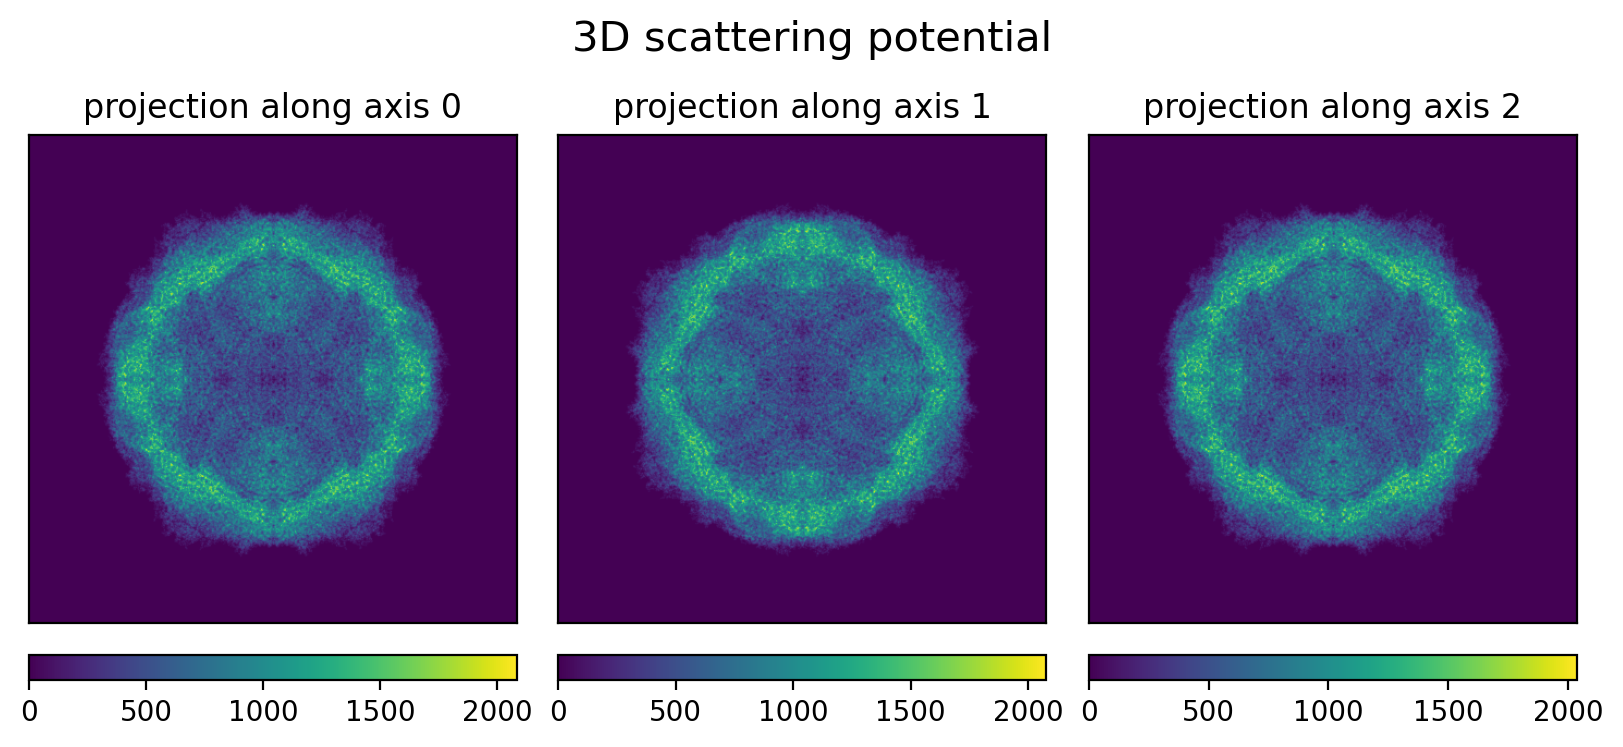

In [7]:
plot3d(V, title="3D scattering potential")

In [4]:
with mrcfile.open("/scratch/loh/joel/empiar-12391/8s7j_448x448x448_I1.mrc") as mrc:
    V = torch.tensor(mrc.data)
V.shape

torch.Size([448, 448, 448])

In [29]:
# with mrcfile.new("/scratch/loh/joel/empiar-12391/8s7j_448x448x448_I1.mrc",
#     overwrite=True,
# ) as mrc:
#     mrc.set_data(V.cpu().numpy())
#     mrc.voxel_size = dx

## Manual rotation of 3D scattering potential (if you want)
Only if you want to pre-rotate the 3D potential before simulating images.

Use-case: maybe you want to simulate in-plane rotations of a different view of the particle.

In [5]:
# y-plane rotation for e.g.
# rotation_angle = torch.tensor(torch.pi / 2)
# rotation_quaternion = torch.tensor(
#     [0, torch.sin(rotation_angle / 2), 0, torch.cos(rotation_angle / 2)]
# )
# rotation_matrix = rotations.quaternion_to_rotation_matrix(rotation_quaternion[None,...])
# affine_matrix = rotations.build_affine_matrix(rotation_matrix, torch.zeros(1,3))
# rotated_V = rotations.rotate_volume(V, affine_matrix)

In [6]:
# plot3d(rotated_V.squeeze(), title="rotated V")

## Generate dataset
Here, you can choose to either use random or in-plane rotations, and random or fixed defocus values (comment/uncomment respectively).

In [32]:
chimera_gaussian_sigma_to_bfactor(0.8)

50.532374533577524

In [58]:
bfactor = 40
filtered = apply_bfactor(V, dx, bfactor)

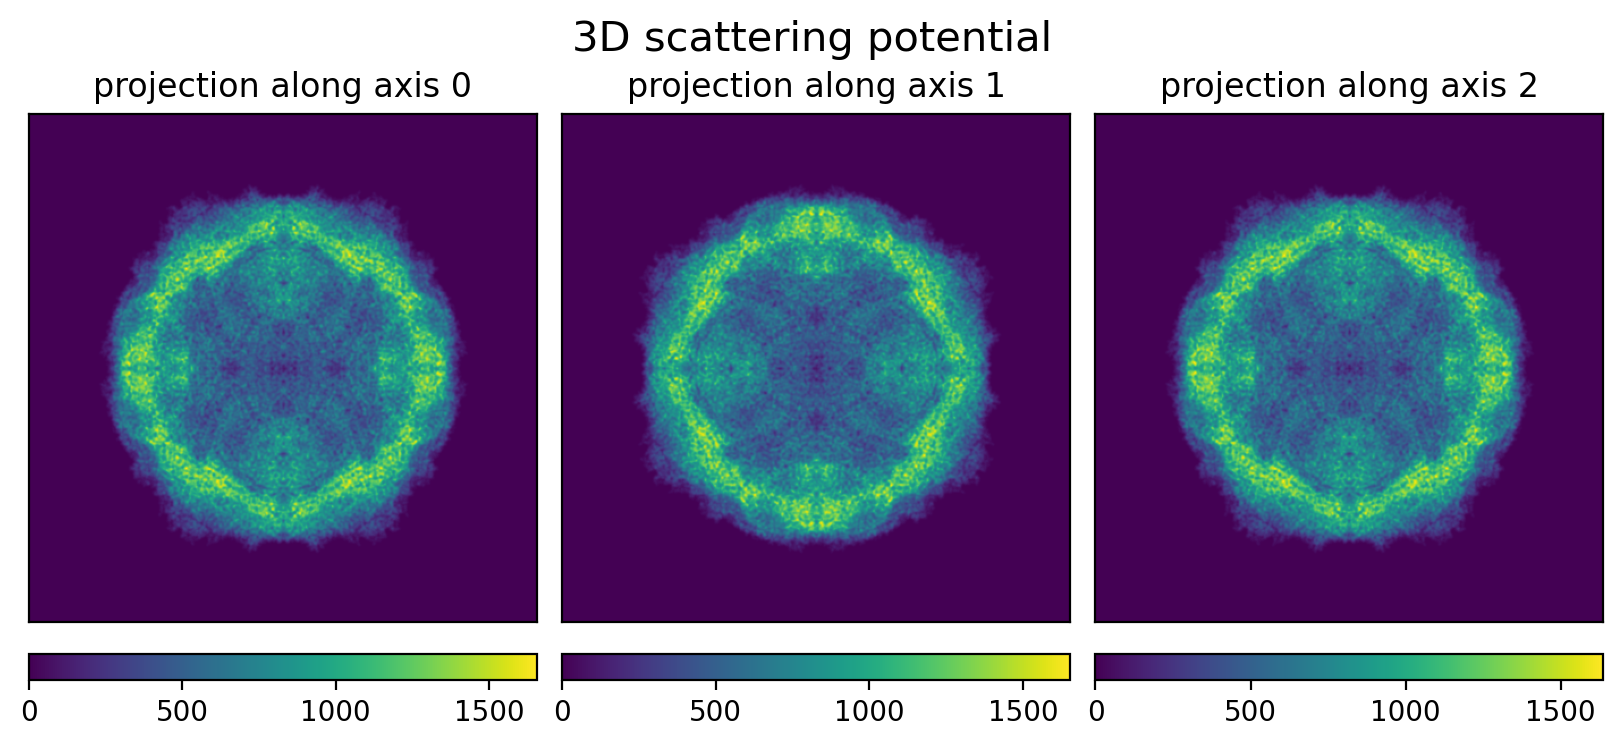

In [59]:
plot3d(filtered, title="3D scattering potential")

In [60]:
n_particles = 3000
energy = 200  # keV
dose_per_angstrom = 40  # e-/A^2
Cs = 1.72e7  # angstrom. Sherical aberration, typical values are 1-3 mm.
alpha = 0.1

In [61]:
# random quaternions
quaternions = torch.stack([rotations.random_quaternion() for i in range(n_particles)])

# in-plane rotations (around z-axis)
# angles = torch.linspace(0, 360, n_particles + 1)
# angles = angles[:-1] / 180 * torch.pi
# quaternions = []
# for a in angles:
#     # (x,y,z,w)
#     quaternions.append(torch.tensor([0, 0, torch.sin(a / 2), torch.cos(a / 2)]))
# quaternions = torch.stack(quaternions)

quaternions.shape

torch.Size([3000, 4])

In [62]:
# random defocus
defocus_min = 8000  # angstrom
defocus_max = 27000  # angstrom
dfang = 0
defocus_A = torch.rand(n_particles) * (defocus_max - defocus_min) + defocus_min

# fixed defocus
# defocus_A = 10000 * torch.ones(n_particles)

ctf_params = torch.stack([torch.tensor([Cs, d, d, dfang]) for d in defocus_A])
ctf_params.shape

torch.Size([3000, 4])

In [63]:
# random shift. set to 0 for no shifts
shift = 0.5  # A
rlnOriginXAngst = 2 * (torch.rand(n_particles) - 0.5) * shift
rlnOriginYAngst = 2 * (torch.rand(n_particles) - 0.5) * shift
translations = torch.stack([rlnOriginXAngst, rlnOriginYAngst], dim=-1)
translations.shape

torch.Size([3000, 2])

In [64]:
device = "cuda:2" #choose cpu if you run out of cuda memory.

In [65]:
# Use multislice, holography, poisson and random_choice to obtain close to experimental conditions.
scattering_model = "multislice"  # 'multislice', 'firstborn', 'projection', 'ctf'
aberration_model = "holography"  # 'holography' or 'ctf'
noise_model = "poisson"  # 'poisson' or None
ice_model = "random_choice"  # 'random_choice' or None

model = ImageGenerator(
    filtered, # or rotated_V
    dx,
    quaternions,
    translations,
    ctf_params,
    energy,
    dose_per_angstrom,
    ice_model=ice_model,
    scattering_model=scattering_model,
    aberration_model=aberration_model,
    noise_model=noise_model,
    klim=None,
    flip_curvature=False,
    alpha=alpha,
).to(device)

In [66]:
idx = torch.arange(n_particles) #new
images = []
batchsize = 5 # set higher or lower for faster/slower generation.
with torch.no_grad():
    for i in tqdm(range(0, n_particles, batchsize)):
        image = model(idx[i : i + batchsize])
        images.append(image.detach().cpu())

images = torch.concat(images, dim=0)
images.shape

100%|█████████████████████████████████████████| 600/600 [03:58<00:00,  2.51it/s]


torch.Size([3000, 448, 448])

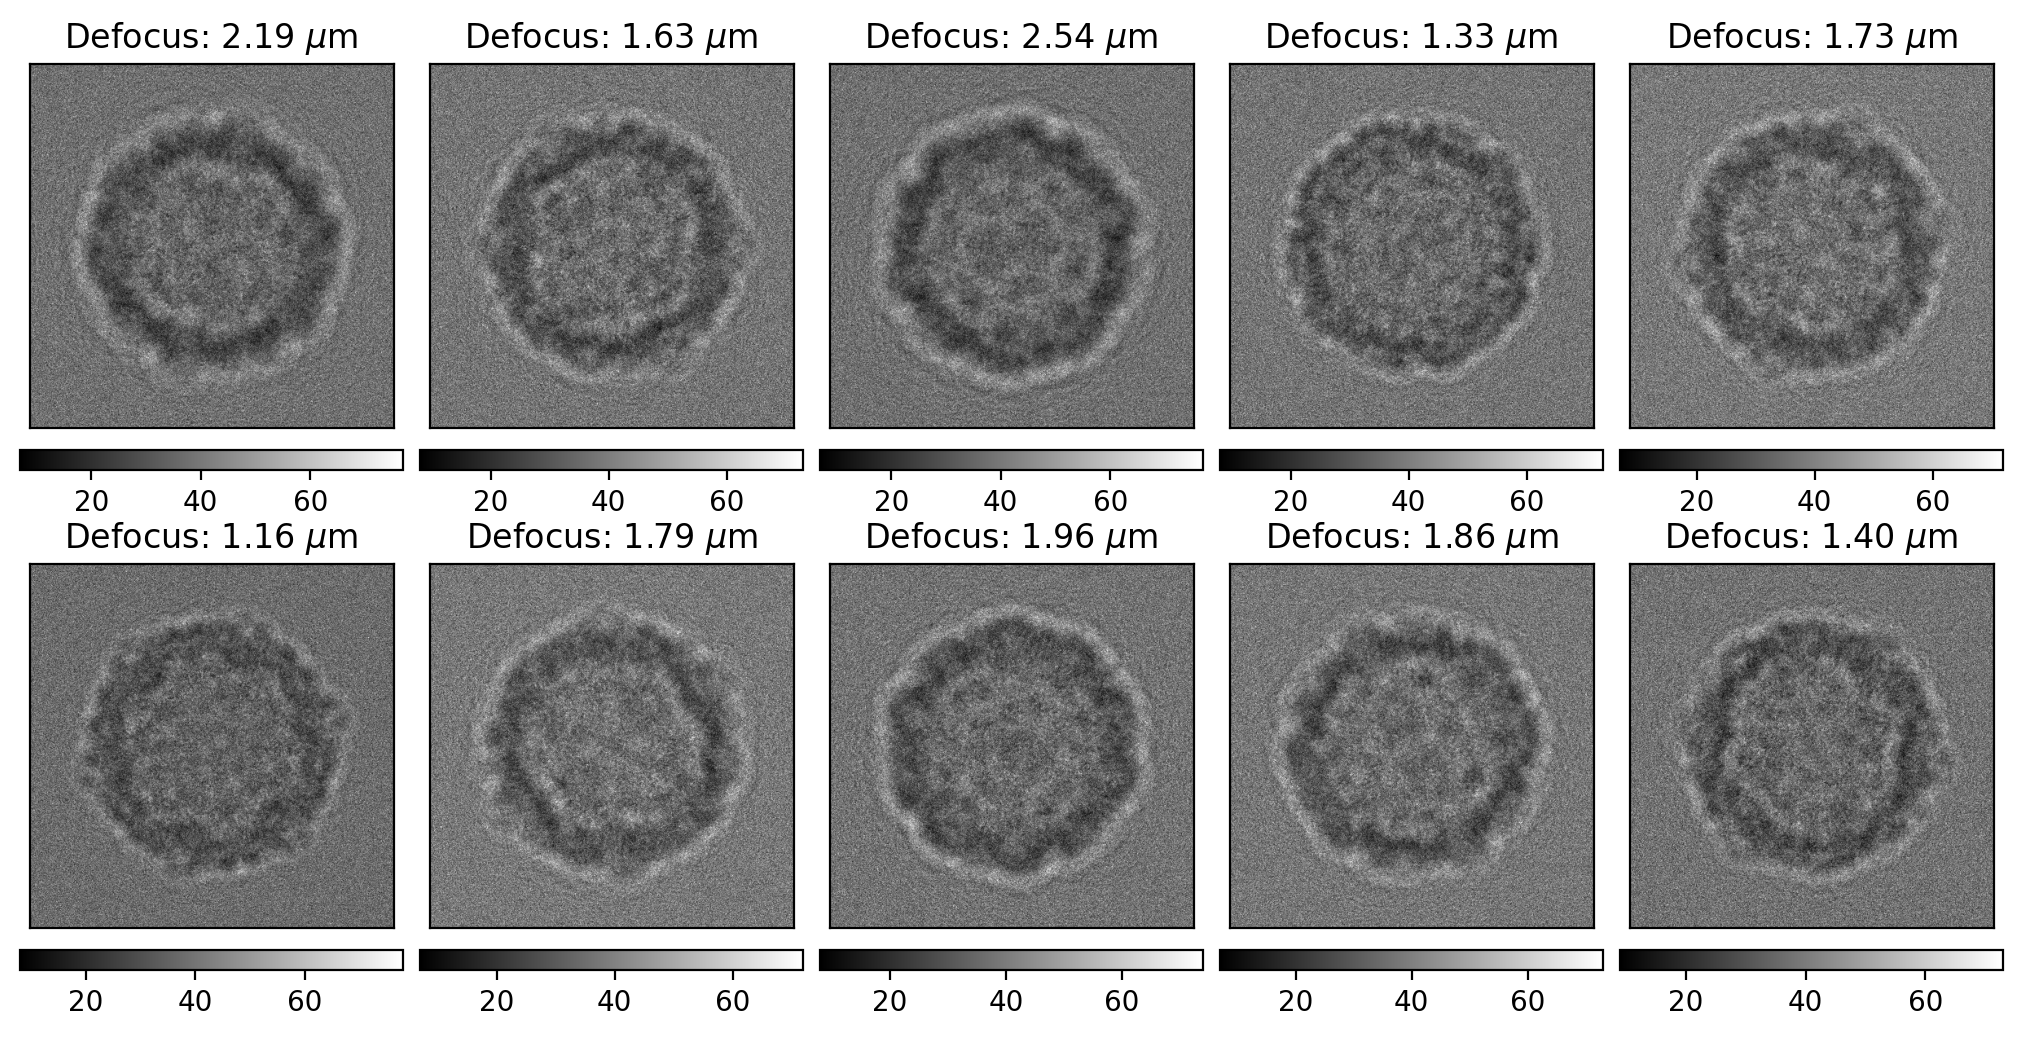

In [67]:
fig, axes = plt.subplots(2, 5, dpi=200, constrained_layout=True, figsize=(10, 5))
for i, ax in enumerate(axes.ravel()):
    im = ax.imshow(images[i], cmap="grey")
    ax.set(xticks=[], yticks=[])
    ax.set_title(f"Defocus: {ctf_params[i,2]/10000:.2f} $\mu$m")
    fig.colorbar(im, ax=ax, location="bottom")
plt.show()

In [68]:
filename = f"/scratch/loh/joel/empiar-12391/simulated_data/3000_random_angles_448x448_40dose_bfactor{bfactor}_18feb2025.h5"

In [69]:
import h5py

In [70]:
with h5py.File(filename, "w") as f:
    f["data/intensities"] = images.detach().cpu().numpy()
    f["data/defocus_A"] = defocus_A
    f["data/orientations"] = quaternions.detach().cpu().numpy()
    f["data/rlnOriginYAngst"] = rlnOriginYAngst
    f["data/rlnOriginXAngst"] = rlnOriginXAngst
    f["params/alpha"] = alpha
    f["params/energy"] = energy
    f["params/cs"] = Cs
    f["params/roi"] = (n,n)
    f["params/dx"] = dx
    f["params/dose_per_angstrom"] = dose_per_angstrom
    f["params/bfactor"] = bfactor

In [71]:
bfactor

40